# EX5 — Turning: the same heading controller with a different goal

**What you will see**
* `counts_per_deg` from wheel track and encoder resolution (a table for three track widths).
* An in-place 90° and 180° turn: P-only overshoots, P + D stops clean — same gains for both angles.
* Why the turn is never exactly right: wheel slip. 20 Monte-Carlo runs → a histogram of the final angle.
* A trapezoidal *angular* profile (EX7's class in degrees) instead of a step target.

```
turn_in_place(angle):
  target_diff = -counts_per_deg * angle         # diff = L − R; a positive (left, CCW) turn needs R > L
  target_dist = current dist                    # forward loop holds position
  loop until |target_diff − diff| < tol for 50 ms:
      fwd  = pid_fwd.update(target_dist − dist)
      turn = pid_head.update(target_diff − diff)
      set_motors(fwd + turn, fwd − turn)
```

In [1]:
from mouse_sim import *

cfg = Config()
print(cfg.summary())

counts/rev = 360   counts/mm = 3.58   counts/cell = 645   counts/deg (L-R) = 5.00
passage = 168 mm   clearance per side = 34 mm   battery = 8.4 V / 8.4 V


## 1. Counts per degree
Each wheel travels an arc `(W/2)·θ` — in opposite directions — so the *difference* `L − R` changes by `W·θ`.
The heading loop acts on the difference, so the constant we need is
`counts_per_deg = counts_per_mm × π·W / 180`   (per wheel it is half of that: `π·W / 360`).

In [2]:
def counts_for_angle(angle_deg, track_m, counts_per_mm):
    """Encoder DIFFERENCE (L - R) for an in-place turn of angle_deg."""
    return counts_per_mm * math.pi * track_m * 1000 / 180.0 * angle_deg

print(f"{'track W':>8} | {'per wheel/deg':>13} | {'diff/deg':>8} | {'diff 90°':>8} | {'diff 180°':>9}")
for W in (0.070, 0.080, 0.090):
    c1 = counts_for_angle(1, W, cfg.counts_per_mm)
    print(f"{W*1000:6.0f} mm | {c1/2:13.2f} | {c1:8.2f} | {c1*90:8.0f} | {c1*180:9.0f}")
print(f"\nwith W = {cfg.track*1000:.0f} mm: 1 count of diff error = {1/cfg.counts_per_deg:.2f}° of heading")

 track W | per wheel/deg | diff/deg | diff 90° | diff 180°
    70 mm |          2.19 |     4.38 |      394 |       788
    80 mm |          2.50 |     5.00 |      450 |       900
    90 mm |          2.81 |     5.62 |      506 |      1012

with W = 80 mm: 1 count of diff error = 0.20° of heading


## 2. The turn loop

In [3]:
def run_turn(cfg, angle_deg, kp_h=2.0, ki_h=0.0, kd_h=0.05, kp_f=1.0, kd_f=0.05,
             profile=None, slip=0.0, seed=0, t_max=1.5, tf=0.02, turn_max=200):
    """profile=(vmax_deg_s, acc_deg_s2) → trapezoidal angular profile instead of a step target."""
    m = DiffDrive(cfg, slip=slip, seed=seed)
    pid_h = PID(kp_h, ki_h, kd_h, tf=tf, umin=-turn_max, umax=turn_max)
    pid_f = PID(kp_f, 0.0, kd_f, tf=tf, umin=-255, umax=255)
    target_total = -cfg.counts_per_deg * angle_deg          # diff = L - R, positive angle = CCW
    prof = None
    if profile:
        prof = Profile(); prof.start(abs(angle_deg), 0.0, profile[0], 0.0, profile[1])
    n = int(t_max / cfg.dt)
    t = np.arange(n) * cfg.dt
    log = {k: np.zeros(n) for k in ("heading", "diff", "target", "turn")}
    for i in range(n):
        cL, cR = m.counts
        dist, diff = (cL + cR) / 2, cL - cR
        if prof:
            prof.update(cfg.dt)
            target = -cfg.counts_per_deg * math.copysign(prof.x_set, angle_deg)
        else:
            target = target_total
        fwd = pid_f.update(0 - dist, cfg.dt)
        turn = pid_h.update(target - diff, cfg.dt)
        m.step(fwd + turn, fwd - turn)
        for k, v in zip(log, (math.degrees(m.theta), diff, target, turn)):
            log[k][i] = v
    return t, log

## 3. 90° and 180°: P only vs P + D (same gains for both)

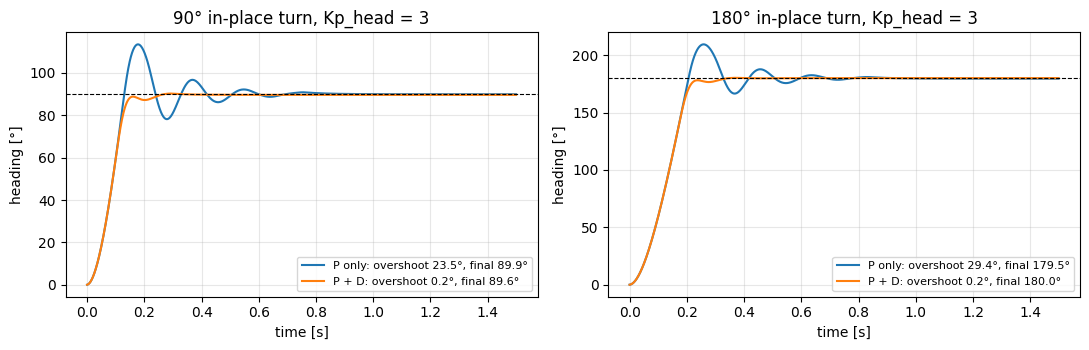

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, ang in zip(axes, (90, 180)):
    for lab, kd in (("P only", 0.0), ("P + D", 0.08)):
        t, R = run_turn(cfg, ang, kp_h=3.0, kd_h=kd)
        ov = R["heading"].max() - ang
        ax.plot(t, R["heading"], label=f"{lab}: overshoot {ov:.1f}°, final {R['heading'][-1]:.1f}°")
    ax.axhline(ang, color="k", ls="--", lw=0.8)
    ax.set_title(f"{ang}° in-place turn, Kp_head = 3"); ax.set_xlabel("time [s]"); ax.set_ylabel("heading [°]")
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); savefig(fig, "ex05_turn_P_vs_PD.png"); plt.show()

**Talking points**
* The heading loop is a *position* loop on `diff`, so the motor lag makes P-only overshoot — D fixes it, exactly as in EX2.
* The final angle is off by a fraction of a degree because the counts are integers: 1 count ≈ 0.4°.
  That is the encoder resolution limit, not a tuning problem.

## 4. Why the constant needs calibrating: wheel slip
During a fast in-place turn the tyres scrub. Here each wheel loses on average 3 % of its motion to slip (random).

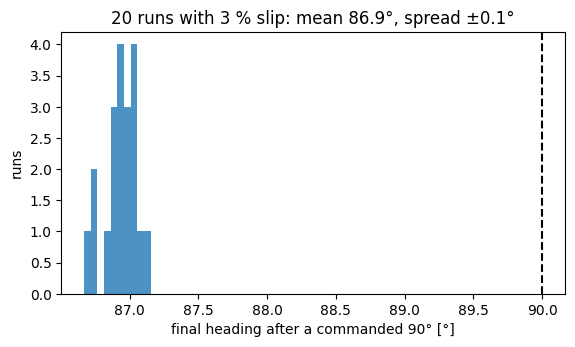

The encoders say 90° every time; the floor says 86.9° on average.
→ effective track W_eff = W × 90 / 86.9 = 82.8 mm  (instead of 80 mm)


In [5]:
finals = []
for seed in range(20):
    t, R = run_turn(cfg, 90, kp_h=3.0, kd_h=0.08, slip=0.03, seed=seed)
    finals.append(R["heading"][-1])
finals = np.array(finals)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(finals, bins=10, color="tab:blue", alpha=0.8)
ax.axvline(90, color="k", ls="--"); ax.set_xlabel("final heading after a commanded 90° [°]"); ax.set_ylabel("runs")
ax.set_title(f"20 runs with 3 % slip: mean {finals.mean():.1f}°, spread ±{finals.std():.1f}°")
savefig(fig, "ex05_slip_histogram.png"); plt.show()
print(f"The encoders say 90° every time; the floor says {finals.mean():.1f}° on average.")
print(f"→ effective track W_eff = W × 90 / {finals.mean():.1f} = {cfg.track*1000*90/finals.mean():.1f} mm  (instead of {cfg.track*1000:.0f} mm)")

#### Track width (`W`) — definition

**The distance between the left and right wheel's contact points with the ground** — measured
side-to-side, straight across the mouse (not front-to-back, and not the wheel diameter).

Picture the mouse from above: draw a line from where the left wheel touches the floor to where the right
wheel touches the floor. That line's length is `W`.

 **Apply it by recomputing `counts_per_deg` with `W_eff` (The effective track width) instead of the nominal `W`, then use that number for every future turn:**

counts_per_deg = counts_per_mm × π × W_eff / 180

target_diff = -counts_per_deg × angle # for every turn command from now on

So `W_eff` doesn't change your code's *structure* — it's a swapped-in constant. Measure it once (the 4×90° test), replace `W` with `W_eff` wherever `counts_per_deg` is computed, and every `turn(angle)` call afterward automatically uses the corrected value.

### Calibration procedure (do this on the floor, with tape)
1. Command **4 × 90°** in the same direction, 1 s pause between. Measure the residual angle (phone protractor / a wall).
2. `W_eff = W × 360 / actual_total_degrees`. Store `counts_per_deg` computed from `W_eff`.
3. Check: 2 × 90° and 1 × 180° must agree within ~1°.
4. Repeat at low battery. If it differs, lower the turn speed or add battery scaling (EX6).
5. Optional: a gyro removes the slip problem for turns entirely (integrate rate → heading; bias-calibrate at start).

## 5. Angular profile instead of a step: smoother, same time

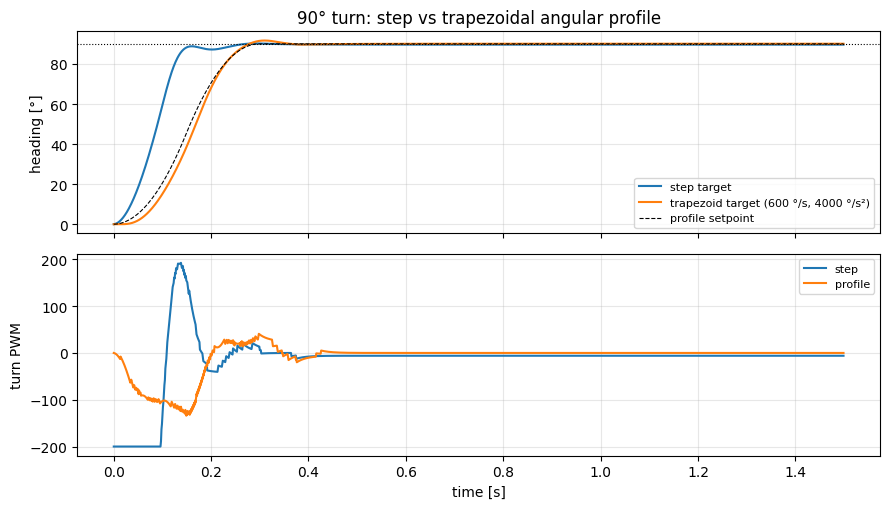

step: reaches 89° at 0.24 s   profile: at 0.27 s


In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True)
t, S = run_turn(cfg, 90, kp_h=3.0, kd_h=0.08)
t, P = run_turn(cfg, 90, kp_h=3.0, kd_h=0.08, profile=(600, 4000))   # 600 °/s, 4000 °/s²
a1.plot(t, S["heading"], label="step target"); a1.plot(t, P["heading"], label="trapezoid target (600 °/s, 4000 °/s²)")
a1.plot(t, -P["target"] / cfg.counts_per_deg, "k--", lw=0.8, label="profile setpoint")
a1.axhline(90, color="k", ls=":", lw=0.8); a1.set_ylabel("heading [°]"); a1.grid(alpha=0.3); a1.legend(fontsize=8)
a2.plot(t, S["turn"], label="step"); a2.plot(t, P["turn"], label="profile"); a2.set_ylabel("turn PWM"); a2.grid(alpha=0.3); a2.legend(fontsize=8)
a2.set_xlabel("time [s]"); a1.set_title("90° turn: step vs trapezoidal angular profile")
fig.tight_layout(); savefig(fig, "ex05_turn_profile.png"); plt.show()
print(f"step: reaches 89° at {t[np.argmax(S['heading'] >= 89)]:.2f} s   profile: at {t[np.argmax(P['heading'] >= 89)]:.2f} s")

**Talking point:** the profile removes the PWM slam at the start (peak turn PWM 134 instead of 200 → less tyre
scrub → the calibration holds better) for ~30 ms of extra time. It is the same `Profile` class as EX7, fed with degrees.
The small overshoot is the loop lagging the moving setpoint — feed-forward (EX7) fixes that.

## Try this
* `slip=0.06` — the spread doubles. This is why fast turns are calibrated separately from slow ones.
* `turn_max=255` — full authority: more slip in a real mouse, no benefit in the sim (the sim has no scrub model beyond `slip`).
* `cfg = replace(cfg, cpr=3)` — a 3-count encoder: 1 count = 1.6°. Can it stop within 1°?

## On your mouse
* Reset both PID integrators when switching between "move" and "turn" modes.
* Small errors will not move the mouse (static friction dead-band): add a minimum PWM offset or a tightly clamped Ki.
* Cap the turn PWM: sliding tyres make the encoders lie.